In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("BAF.csv")
df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.8,0.124690,-1,143,30,0.051348,-0.826239,AB,530,...,0,1500.0,0,INTERNET,16.967770,other,0,1,0,7
999996,0,0.9,0.824544,-1,193,30,0.009591,0.008307,AC,408,...,1,1000.0,0,INTERNET,1.504109,macintosh,0,1,0,7
999997,0,0.8,0.140891,-1,202,10,0.059287,50.609995,AA,749,...,0,200.0,0,INTERNET,16.068595,other,0,1,0,7
999998,0,0.9,0.002480,52,3,30,0.023357,-1.313387,AB,707,...,0,200.0,0,INTERNET,1.378683,linux,1,1,0,7


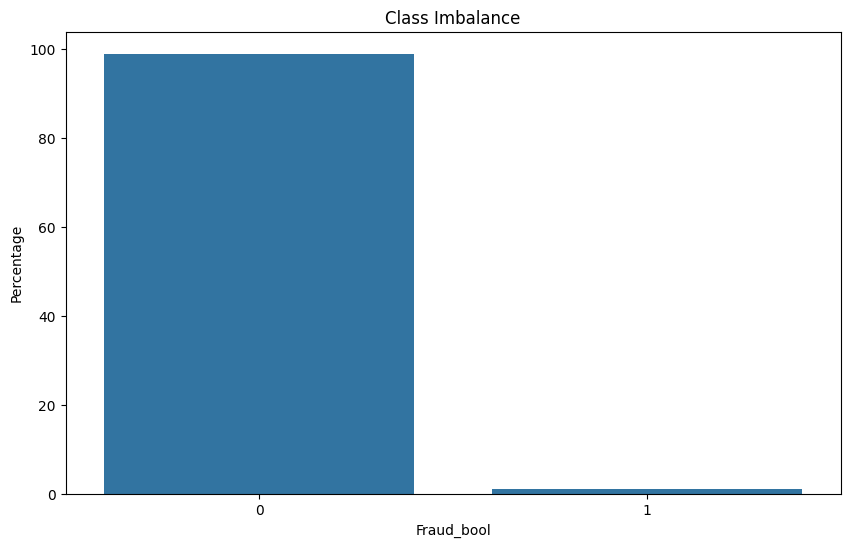

In [4]:
# Visualizing the severity of the class imbalance in the target variable 

plt.figure(figsize = (10,6))
sns.countplot(data = df, x = "fraud_bool",stat = "percent")
plt.title("Class Imbalance")
plt.xlabel("Fraud_bool")
plt.ylabel("Percentage")
plt.show()

In [5]:
# As you can see in the figure above. There is extreme class imbalance in the target variable which needs a fix

In [6]:
df['fraud_bool'].unique()

array([0, 1])

In [7]:
# We want to find outliers but since we are dealing with high-dimentional data and highly imbalanced then we need to use 
# a better method than IQR for handling outliers. which means we are going to do univariate outlier detection by making a histogram for each feature 
# then do multivariate outlier detection using principal componenet analysis (PCA)

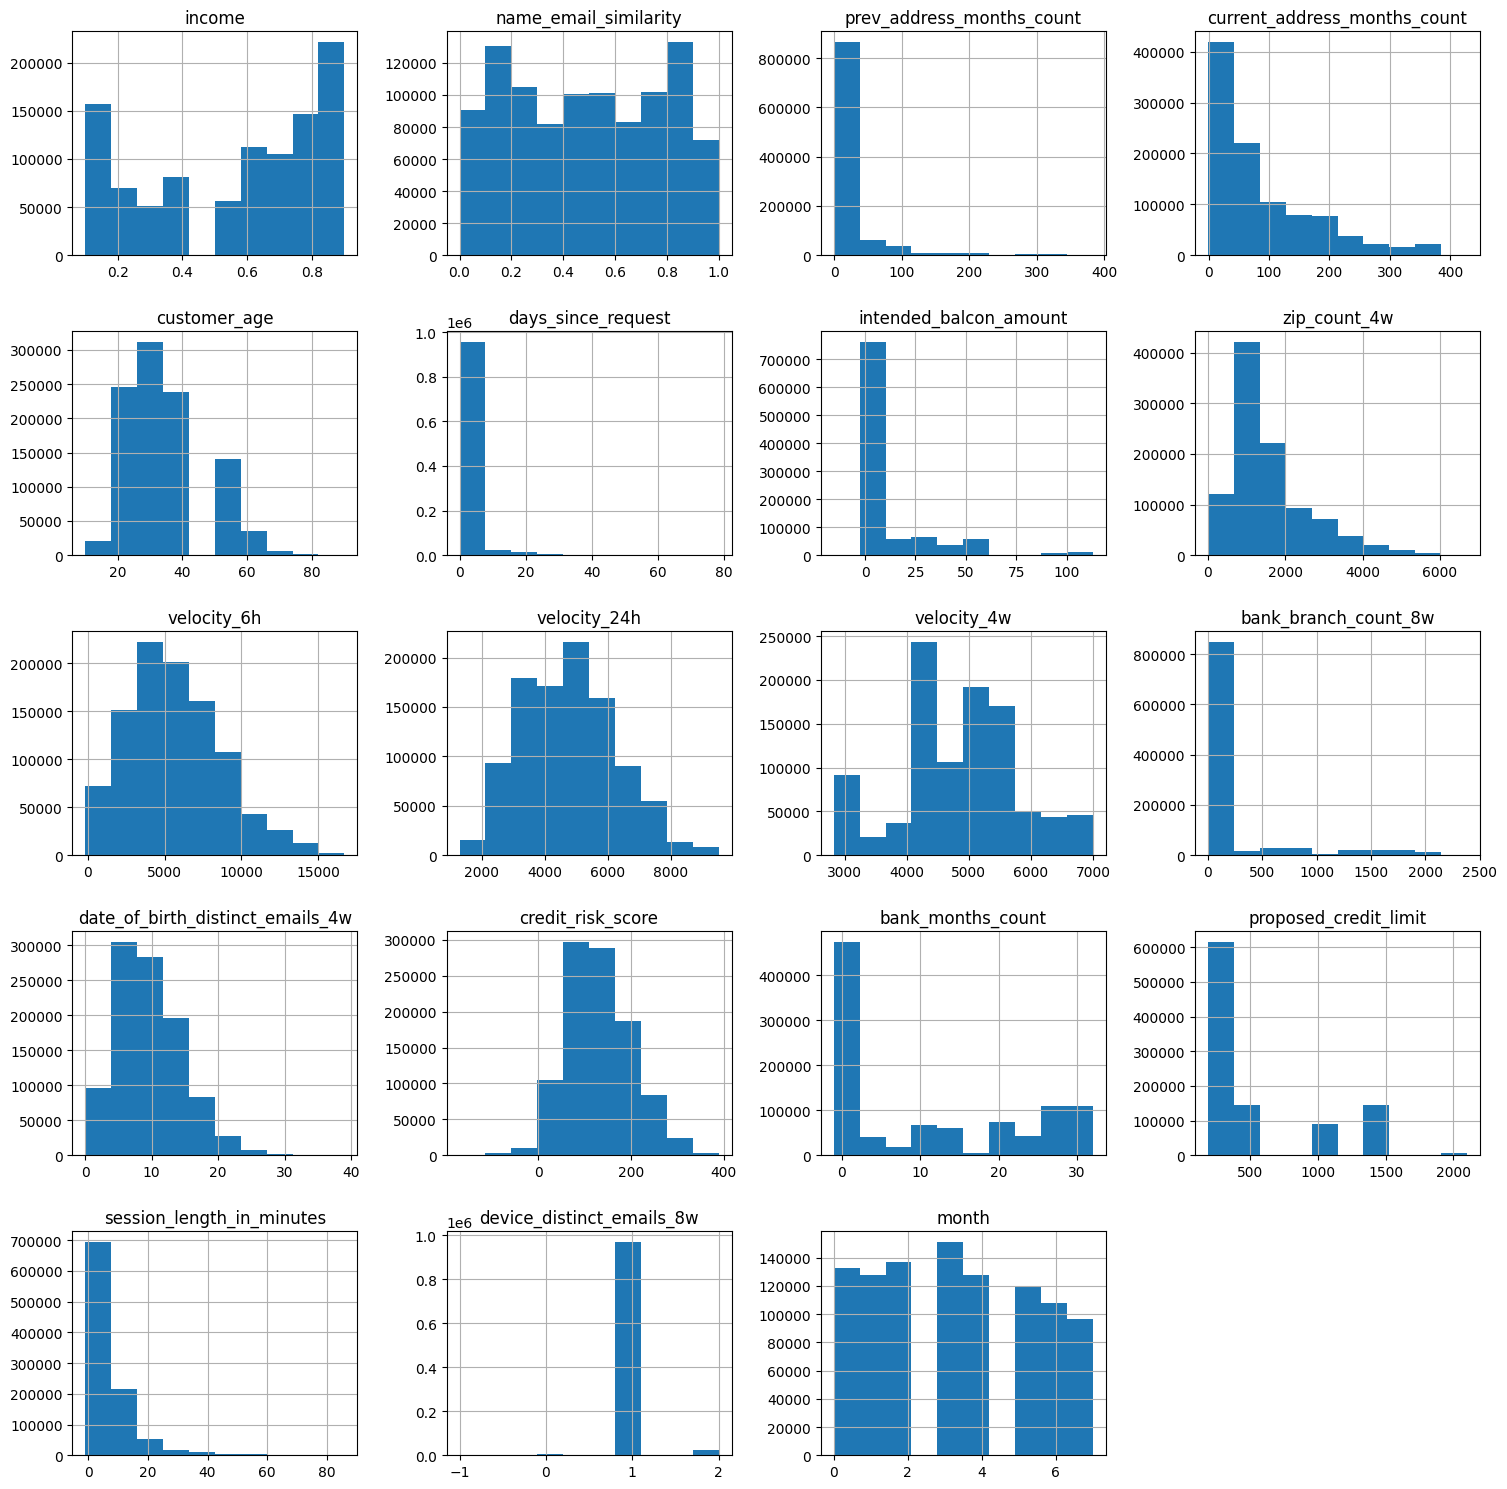

In [8]:
# Univariate Outlier detection:
columns = list()
for i in df.select_dtypes(include = 'number').columns:
    if len(df[i].unique().tolist()) <= 2:
        columns.append(i)

df2 = df.drop(columns = columns)
df2.hist(figsize=(15, 15))
plt.tight_layout()
plt.show()


In [9]:
# As we can see in the plots above here are the columns that have possible outliers:
# 1- prev_address_months_count: most of the values are clustered between 0 and 50, and tail is stretching to 300
# 2- current_address_months_count: most values are clustered between 0 and 200, and tail is stretching to 400
# 3- days_since_request: most values are clustered between 0 and 10, and tail stretching to 30
# 4- intended_balcon_amount: values clustered around 0, yet tail stretching to 100
# 5- bank_branch_count_8w: values clustered around 0, yet tail stretching to 2000s
# 6- bank_months_count: values clustered around 0, yet tail stretching up to 30
# 7- proposed_credit_limit: 2000 is an outlier
# 8- session_length_in_minutes: most values are clustered around 0 and 10, yet tail streching to 60
# 9- device_distinct_emails_8w: -1 is an outlier (and the value doesn't make any sense)

In [14]:
# Multivariate Outlier Detection:
pca = PCA(n_components = 2)
df2 = df2.select_dtypes(include = "number")
X = df2.to_numpy()
X_scaled = StandardScaler().fit_transform(X)
pca_result = pca.fit_transform(X_scaled)
explained_pca_variance = pca.explained_variance_ratio_
pca_df = pd.DataFrame(data = pca_result,columns = ['PC1','PC2'])
pca_df['fraud_bool'] = df['fraud_bool']

In [15]:
print('2-component pca only captures',sum(explained_pca_variance),'of the data')

2-component pca only captures 0.25680393803473694 of the data


<Axes: xlabel='PC1', ylabel='PC2'>

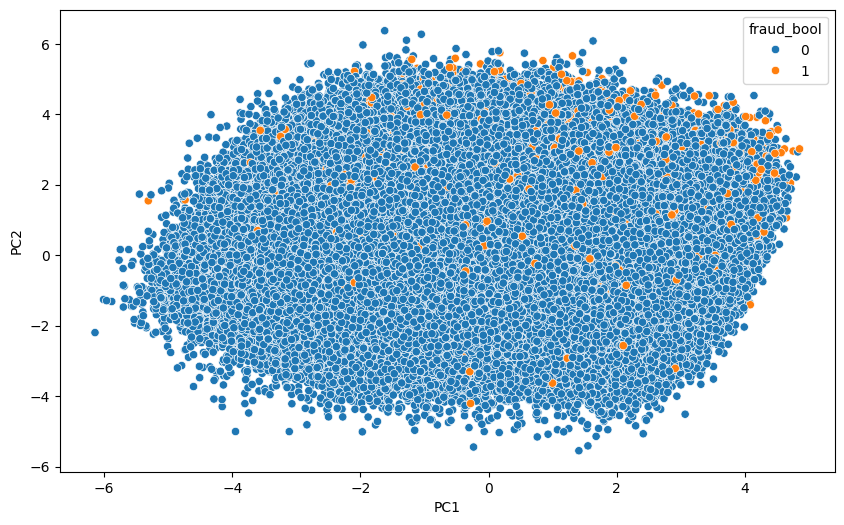

In [17]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = pca_df, x = 'PC1',y = 'PC2',hue = 'fraud_bool')

In [ ]:
# In the multivariate plot above we don't see any extreme outliers, but it tells us that the fraud cases are scattered through the cloud
# hence why the 2-component pca is only capturing 30% of the total variance indicating that this is a hard classification problem